# Software Development Oriented to Machine Learning

This notebook explores a dataset of potentially hazardous asteroids and develops a baseline regression model to predict impact probability.

The analysis includes data exploration, preprocessing, visualization, model training, and evaluation.
## Contents

1. [Importing Libraries](#1-importing-libraries)
2. [Loading the Dataset](#2-loading-the-dataset)
   - [2.1 Dataset Overview](#21-dataset-overview)
   - [2.2 Missing Values](#22-missing-values)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
   - [3.1 Correlation Analysis](#31-correlation-analysis)
   - [3.2 Impact Probability Distribution](#32-impact-probability-distribution)
   - [3.3 Risk and Asteroid Characteristics](#33-risk-and-asteroid-characteristics)
   - [3.4 Potential Impact Timeline](#34-potential-impact-timeline)
4. [Data Preprocessing](#4-data-preprocessing)
   - [4.1 Handling Missing Values](#41-handling-missing-values)
   - [4.2 Target Transformation](#42-target-transformation)
   - [4.3 Feature Selection](#43-feature-selection)
   - [4.4 Train-Test Split](#44-train-test-split)
   - [4.5 Feature Scaling](#45-feature-scaling)
5. [Baseline Model](#5-baseline-model)
   - [5.1 Model Architecture](#51-model-architecture)
   - [5.2 Model Training](#52-model-training)
   - [5.3 Model Evaluation](#53-model-evaluation)
6. [Results](#6-results)
   - [6.1 Training History](#61-training-history)
   - [6.2 Model Performance](#62-model-performance)
7. [Conclusions](#7-conclusions)



## 1. Importing Libraries

In [51]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers

## 2. Loading the Dataset

The dataset contains information about near-Earth objects and their potential impact risk. It includes orbital characteristics, impact probabilities, Palermo and Torino scales, and information about potential encounter years.

### 2.1 Dataset Overview

In [52]:
from pathlib import Path

from software_development_ml_practice_1.config import RAW_DATA_DIR

DATASET_URI = "hf://datasets/juliensimon/sentry-impact-risk/data/sentry_impact_risk.parquet"
SAMPLE_PATH = RAW_DATA_DIR / "sentry_impact_risk_sample.parquet"

if SAMPLE_PATH.exists():
    df = pd.read_parquet(SAMPLE_PATH)
    print(f"Loaded local sample with {len(df)} rows from {SAMPLE_PATH}")
else:
    df = pd.read_parquet(DATASET_URI)
    RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
    df.sample(n=min(500, len(df)), random_state=42).to_parquet(SAMPLE_PATH, index=False)
    print(f"Downloaded {len(df)} rows and saved a sample to {SAMPLE_PATH}")

df.head()

Loaded local sample with 500 rows from /home/ruthaltmno/SoftwareDevelopmentML/software_development_ml_practice_1/data/raw/sentry_impact_risk_sample.parquet


,torino_scale,n_potential_impacts,last_observation,designation,impact_probability,palermo_scale_cum,last_observation_jd,full_name,v_infinity_kms,absolute_magnitude,diameter_km,palermo_scale_max,year_range_min,year_range_max
0,0.0,32,2026-06-14,2026 LX,8.152456e-05,-6.27,2461205.5,(2026 LX),7.572845,28.85,0.0057,-6.52,2083,2126
1,0.0,3,2015-06-24,2015 MN11,4.232570e-07,-5.92,2457197.5,(2015 MN11),21.067492,24.51,0.0420,-5.93,2081,2105
2,0.0,1,2024-05-09,2024 JN,1.932000e-08,-9.74,2460439.5,(2024 JN),3.050000,28.25,0.0076,-9.74,2110,2110
3,0.0,1,2004-11-22,2004 WC1,1.094000e-07,-7.98,2453331.5,(2004 WC1),5.980000,26.20,0.0190,-7.98,2117,2117
4,0.0,1,2022-02-10,2022 CL3,1.110000e-06,-7.68,2459620.5,(2022 CL3),8.740000,28.13,0.0080,-7.68,2093,2093


In [53]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   torino_scale         500 non-null    float64       
 1   n_potential_impacts  500 non-null    int64         
 2   last_observation     500 non-null    datetime64[us]
 3   designation          500 non-null    object        
 4   impact_probability   500 non-null    float64       
 5   palermo_scale_cum    500 non-null    float64       
 6   last_observation_jd  500 non-null    float64       
 7   full_name            500 non-null    object        
 8   v_infinity_kms       499 non-null    float64       
 9   absolute_magnitude   500 non-null    float64       
 10  diameter_km          500 non-null    float64       
 11  palermo_scale_max    500 non-null    float64       
 12  year_range_min       500 non-null    Int64         
 13  year_range_max       500 non-null  

,torino_scale,n_potential_impacts,last_observation,impact_probability,palermo_scale_cum,last_observation_jd,v_infinity_kms,absolute_magnitude,diameter_km,palermo_scale_max,year_range_min,year_range_max
count,500.0,500.000000,500,5.000000e+02,500.000000,5.000000e+02,499.000000,500.000000,500.000000,500.000000,500.0,500.0
mean,0.0,22.464000,2019-02-24 11:51:21.600000,9.383971e-05,-6.884740,2.458539e+06,10.953738,27.370880,0.016427,-7.102140,2078.744,2107.814
min,0.0,1.000000,1994-04-10 00:00:00,1.221000e-10,-11.460000,2.449452e+06,0.977447,19.920000,0.001300,-11.460000,2029.0,2031.0
25%,0.0,2.000000,2015-10-14 18:00:00,2.562925e-07,-7.832500,2.457310e+06,7.158735,26.390000,0.006875,-8.022500,2060.75,2100.75
50%,0.0,6.000000,2020-11-02 12:00:00,2.644352e-06,-6.820000,2.459156e+06,9.979882,27.515000,0.011000,-7.120000,2079.0,2118.0
75%,0.0,19.000000,2024-02-03 00:00:00,2.691060e-05,-5.760000,2.460344e+06,13.770080,28.462500,0.018000,-6.020000,2098.0,2122.0
max,0.0,418.000000,2026-09-13 00:00:00,1.154397e-02,-3.610000,2.461296e+06,36.460000,32.070000,0.350000,-3.760000,2124.0,2126.0
std,0.0,45.681663,NaN,6.061134e-04,1.499288,2.289042e+03,5.539756,1.749763,0.022145,1.466745,23.774038,20.387808


### 2.2 Missing Values

Before preprocessing the data, we inspect the dataset for missing values.

In [54]:
missing_values = df.isna().sum()

missing_values

torino_scale           0
n_potential_impacts    0
last_observation       0
designation            0
impact_probability     0
palermo_scale_cum      0
last_observation_jd    0
full_name              0
v_infinity_kms         1
absolute_magnitude     0
diameter_km            0
palermo_scale_max      0
year_range_min         0
year_range_max         0
dtype: int64

In [55]:
missing_percentage = (
    df.isna().mean() * 100
).sort_values(ascending=False)

missing_percentage

v_infinity_kms         0.2
torino_scale           0.0
last_observation       0.0
designation            0.0
impact_probability     0.0
n_potential_impacts    0.0
palermo_scale_cum      0.0
last_observation_jd    0.0
full_name              0.0
absolute_magnitude     0.0
diameter_km            0.0
palermo_scale_max      0.0
year_range_min         0.0
year_range_max         0.0
dtype: float64

## 3. Exploratory Data Analysis

This section explores the numerical relationships and distributions in the dataset before training the regression model.

### 3.1 Correlation Analysis

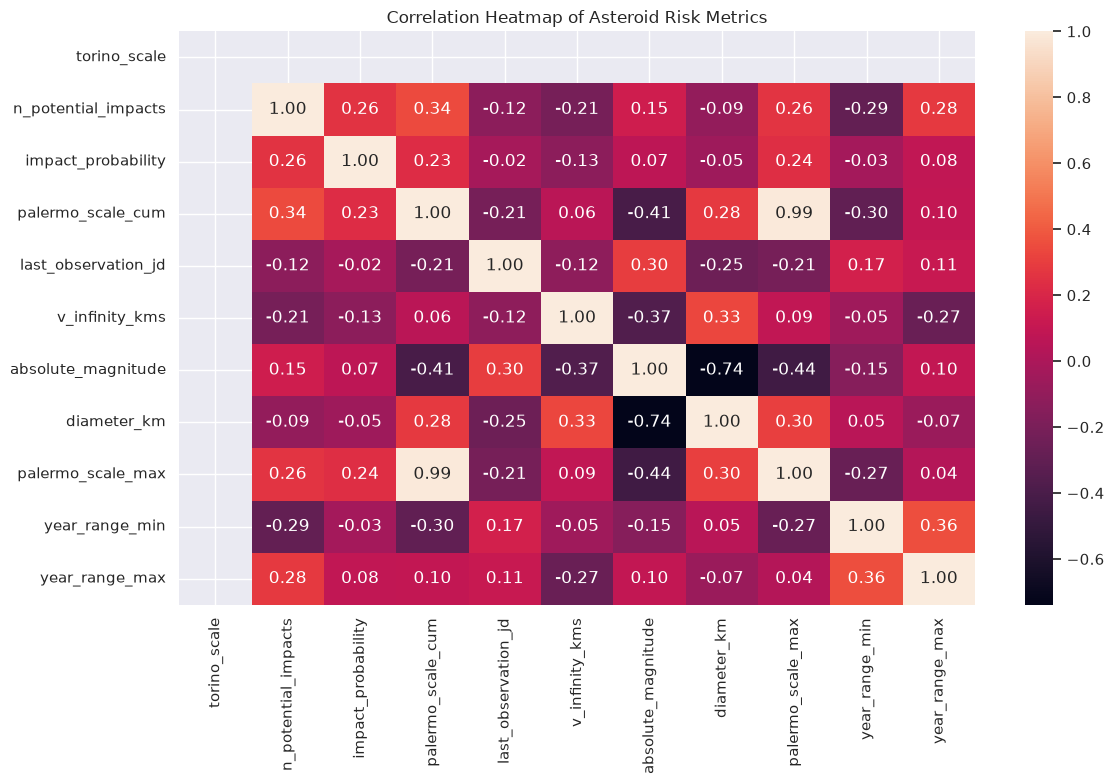

In [56]:
numeric_cols = df.select_dtypes(include="number")

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    fmt=".2f",
)

plt.title("Correlation Heatmap of Asteroid Risk Metrics")
plt.tight_layout()
plt.show()

### 3.2 Impact Probability Distribution

Impact probabilities are very small values. A logarithmic transformation makes their distribution easier to visualize.

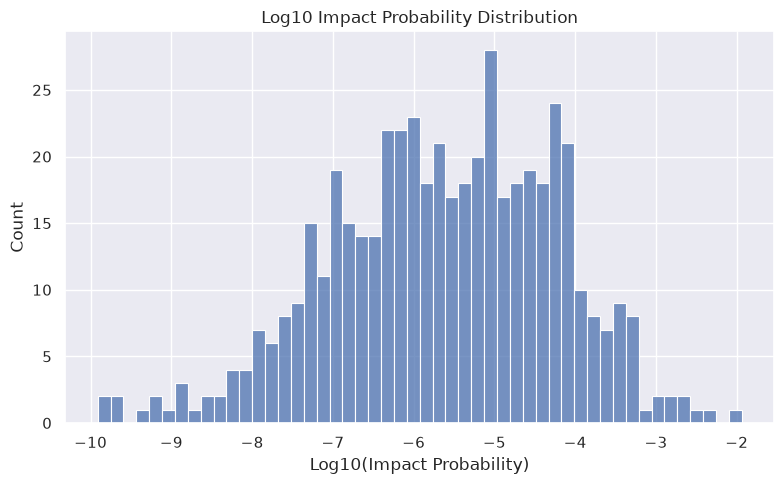

In [57]:
plt.figure(figsize=(8, 5))

sns.histplot(
    np.log10(df["impact_probability"]),
    bins=50,
)

plt.title("Log10 Impact Probability Distribution")
plt.xlabel("Log10(Impact Probability)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 3.3 Risk and Asteroid Characteristics

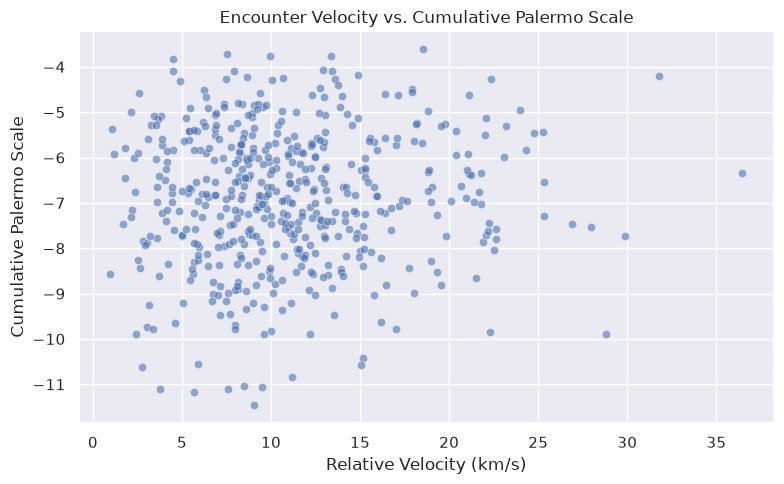

In [58]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="v_infinity_kms",
    y="palermo_scale_cum",
    alpha=0.6,
)

plt.title("Encounter Velocity vs. Cumulative Palermo Scale")
plt.xlabel("Relative Velocity (km/s)")
plt.ylabel("Cumulative Palermo Scale")
plt.tight_layout()
plt.show()

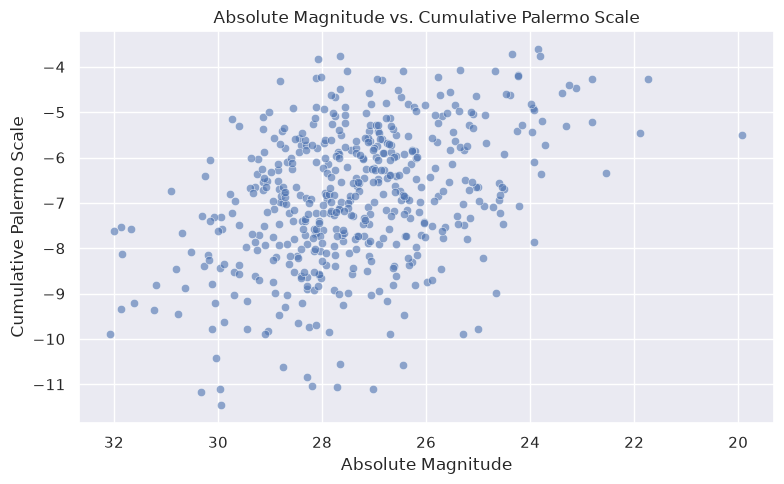

In [59]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="absolute_magnitude",
    y="palermo_scale_cum",
    alpha=0.6,
)

plt.gca().invert_xaxis()

plt.title("Absolute Magnitude vs. Cumulative Palermo Scale")
plt.xlabel("Absolute Magnitude")
plt.ylabel("Cumulative Palermo Scale")
plt.tight_layout()
plt.show()

### 3.4 Potential Impact Timeline

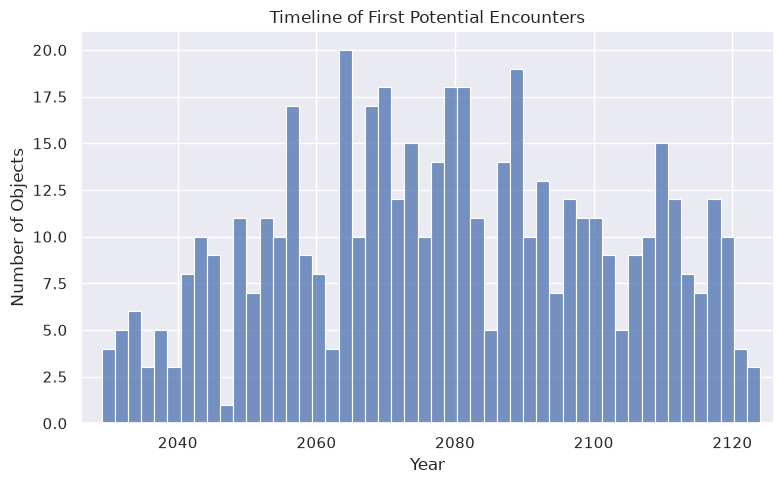

In [60]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["year_range_min"].dropna(),
    bins=50,
)

plt.title("Timeline of First Potential Encounters")
plt.xlabel("Year")
plt.ylabel("Number of Objects")
plt.xlim(2026, 2126)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

Before training the regression model, the dataset is cleaned and transformed. Missing values are removed, the target variable is transformed logarithmically, relevant numerical features are selected, and the data is divided into training and test sets.

### 4.1 Handling Missing Values

In [61]:
df_reg = df.dropna().copy()

print(f"Original dataset size: {len(df)}")
print(f"Dataset size after removing missing values: {len(df_reg)}")

Original dataset size: 500
Dataset size after removing missing values: 499


### 4.2 Target Transformation

The impact probability values are very small. Therefore, the target variable is transformed using the base-10 logarithm.

In [62]:
df_reg["log_impact_probability"] = np.log10(
    df_reg["impact_probability"]
)

### 4.3 Feature Selection

In [63]:
features = df_reg.select_dtypes(include="number").columns.tolist()

features.remove("impact_probability")
features.remove("log_impact_probability")

X = df_reg[features]
y = df_reg["log_impact_probability"]

print("Selected features:")
print(features)

print(f"\nNumber of features: {X.shape[1]}")

Selected features:
['torino_scale', 'n_potential_impacts', 'palermo_scale_cum', 'last_observation_jd', 'v_infinity_kms', 'absolute_magnitude', 'diameter_km', 'palermo_scale_max', 'year_range_min', 'year_range_max']

Number of features: 10


### 4.4 Train-Test Split

The dataset is divided into training and test sets. The test set contains 20% of the observations and is kept separate for the final model evaluation.

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 399
Test samples: 100


### 4.5 Feature Scaling

The numerical features are standardized using `StandardScaler`. The scaler is fitted only on the training data to avoid data leakage.

In [65]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 5. Baseline Model

A baseline neural network is trained to predict the logarithm of the impact probability. The model provides a first reference point for evaluating the performance of the regression approach.

### 5.1 Model Architecture

The model is a simple feed-forward neural network with two hidden layers. ReLU activation is used in the hidden layers, while the output layer contains a single neuron because this is a regression problem.

In [66]:
model = tf.keras.Sequential(
    [
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(1),
    ]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,929 (19.25 KB)

 Trainable params: 4,929 (19.25 KB)

 Non-trainable params: 0 (0.00 B)

### 5.2 Model Training

The model is trained using the Adam optimizer and Mean Squared Error (MSE) as the loss function. Mean Absolute Error (MAE) is also monitored during training.

A validation split of 10% of the training data is used to monitor the model's performance on unseen data during training.

In [67]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"],
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=2,
)

Epoch 1/10


6/6 - 2s - 344ms/step - loss: 36.2205 - mae: 5.8384 - val_loss: 37.3114 - val_mae: 5.8924
Epoch 2/10
6/6 - 0s - 37ms/step - loss: 31.7079 - mae: 5.4456 - val_loss: 32.5582 - val_mae: 5.4831
Epoch 3/10
6/6 - 0s - 32ms/step - loss: 27.3940 - mae: 5.0395 - val_loss: 27.9958 - val_mae: 5.0548
Epoch 4/10
6/6 - 0s - 26ms/step - loss: 23.0097 - mae: 4.5964 - val_loss: 23.3773 - val_mae: 4.5787
Epoch 5/10
6/6 - 0s - 25ms/step - loss: 18.7182 - mae: 4.1020 - val_loss: 18.5419 - val_mae: 4.0190
Epoch 6/10
6/6 - 0s - 25ms/step - loss: 14.4575 - mae: 3.5417 - val_loss: 13.7685 - val_mae: 3.4258
Epoch 7/10
6/6 - 0s - 31ms/step - loss: 10.4588 - mae: 2.9303 - val_loss: 9.5453 - val_mae: 2.8023
Epoch 8/10
6/6 - 0s - 28ms/step - loss: 7.1601 - mae: 2.3684 - val_loss: 6.4209 - val_mae: 2.2449
Epoch 9/10
6/6 - 0s - 41ms/step - loss: 4.8894 - mae: 1.8881 - val_loss: 4.6511 - val_mae: 1.9106
Epoch 10/10
6/6 - 0s - 29ms/step - loss: 3.7528 - mae: 1.6184 - val_loss: 4.0122 - val_mae: 1.6826


### 5.3 Model Evaluation

After training, the model is evaluated on the test set. The test data has not been used during training or validation, providing an independent estimate of the model's performance.

In [68]:
test_loss, test_mae = model.evaluate(
    X_test,
    y_test,
    verbose=0,
)

print(f"Test MSE: {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")

Test MSE: 7.3219
Test MAE: 1.6406


## 6. Results

This section visualizes the training process and summarizes the performance of the baseline regression model.

### 6.1 Training History

The training and validation curves show how the model's error changes throughout the training process. Comparing both curves helps identify whether the model is learning effectively and whether there are signs of overfitting.

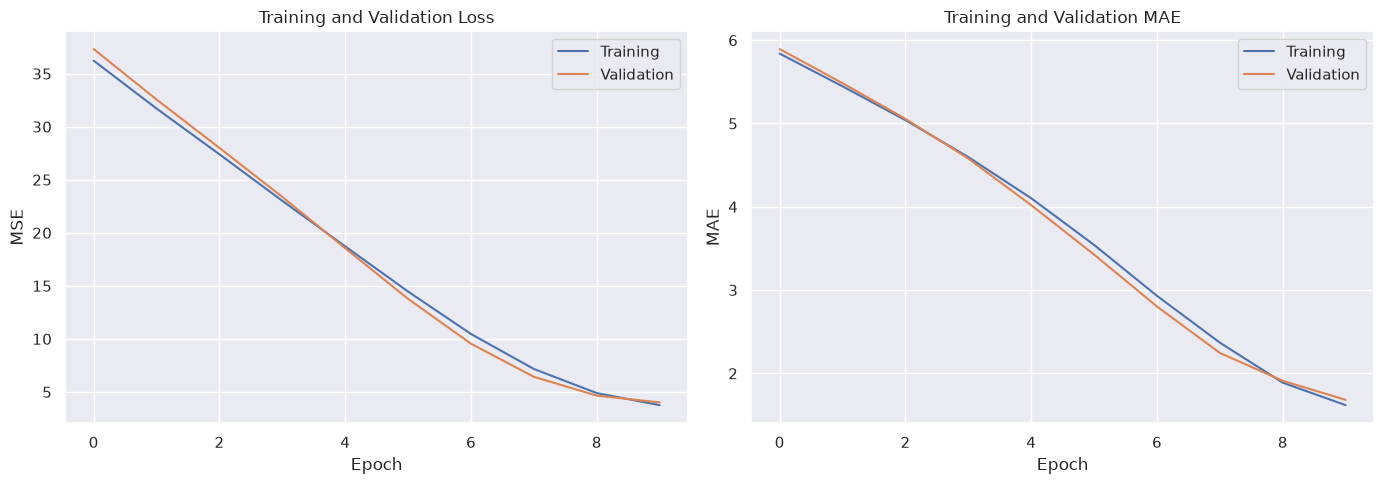

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    history.history["loss"],
    label="Training",
)
axes[0].plot(
    history.history["val_loss"],
    label="Validation",
)

axes[0].set_title("Training and Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()


axes[1].plot(
    history.history["mae"],
    label="Training",
)
axes[1].plot(
    history.history["val_mae"],
    label="Validation",
)

axes[1].set_title("Training and Validation MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()

plt.tight_layout()
plt.show()

### 6.2 Model Performance

The baseline model achieves the following performance on the test set:

In [70]:
results = pd.DataFrame(
    {
        "Metric": ["MSE", "MAE"],
        "Test value": [test_loss, test_mae],
    }
)

results

,Metric,Test value
0,MSE,7.321929
1,MAE,1.640607


## 7. Conclusions

The dataset contains several numerical variables related to asteroid characteristics and potential impact risk. Exploratory analysis was used to understand the relationships between these variables before training the model.

A baseline neural network was trained to predict the logarithm of the impact probability. The model provides a first reference for the regression task, with the training history showing how the error changes during learning.

This baseline can be used as a starting point for future experiments with different model architectures, hyperparameters, preprocessing techniques, or alternative regression algorithms.

## 8. Saved Deliverables

The following cell saves the main exploratory and performance visualizations as PNG files in `reports/figures/`. This makes the analysis reproducible outside the notebook and provides the figures required for the project report.

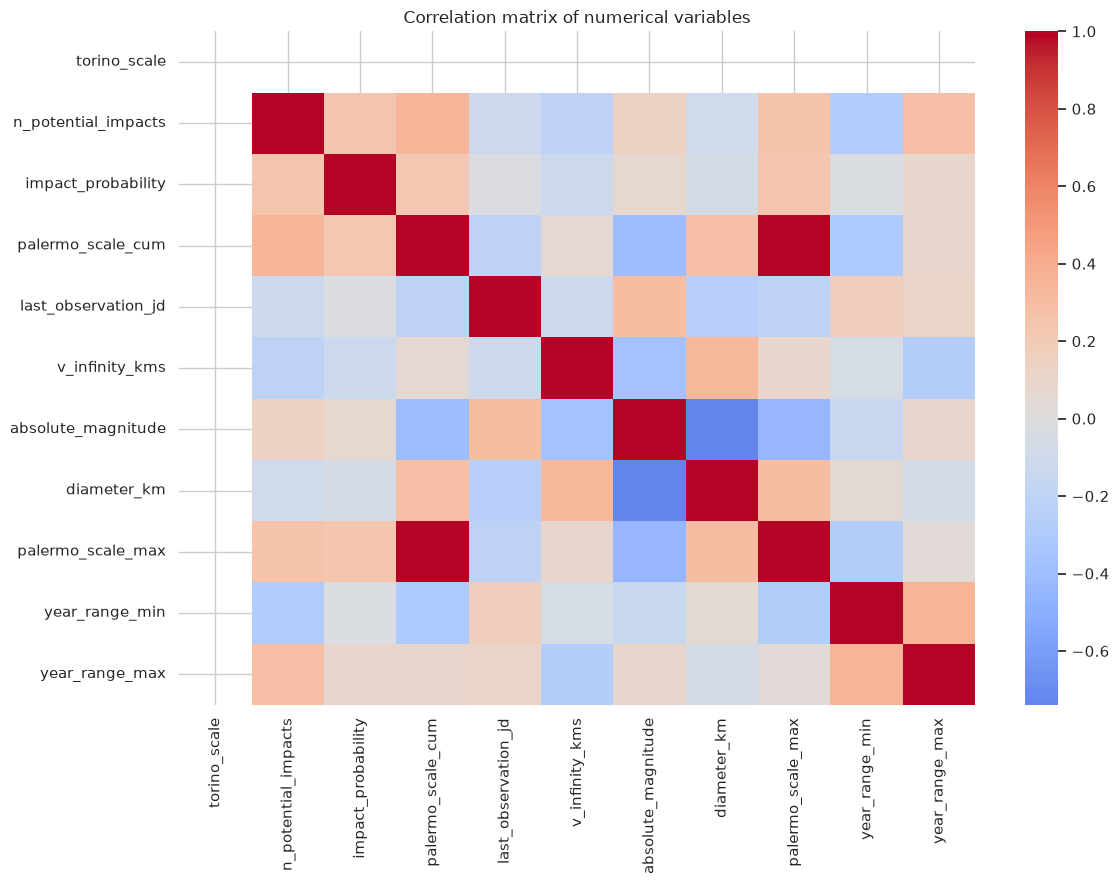

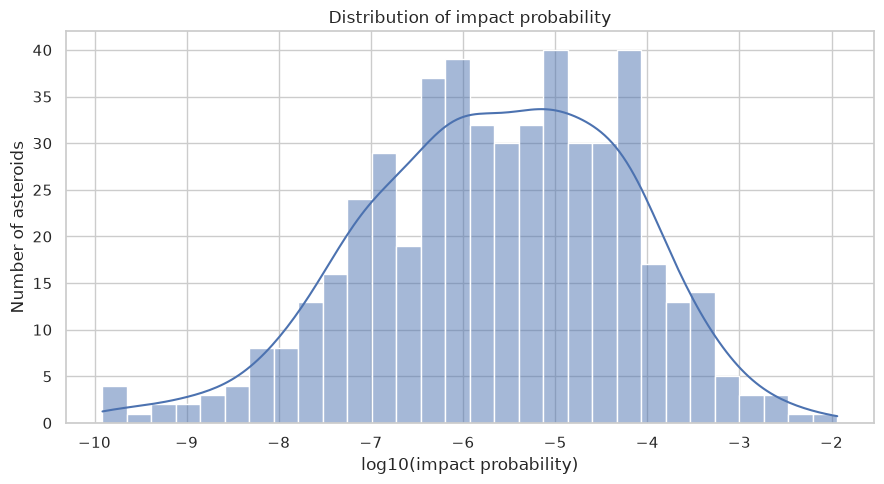

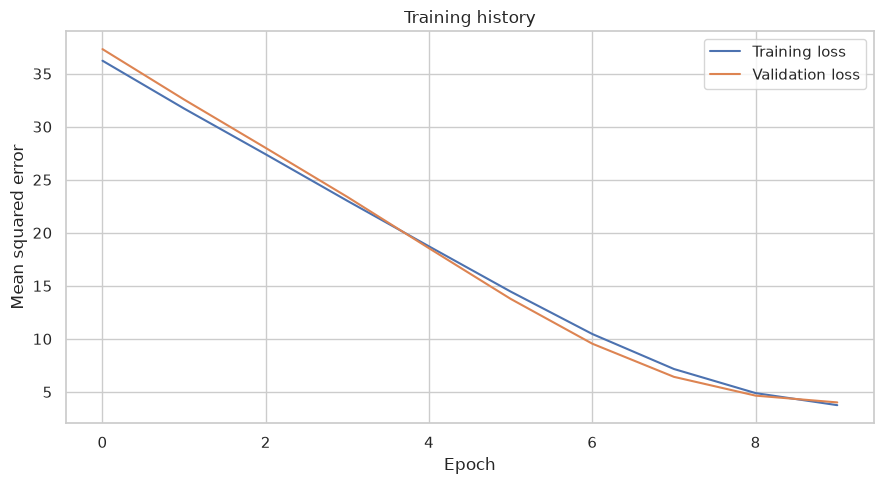

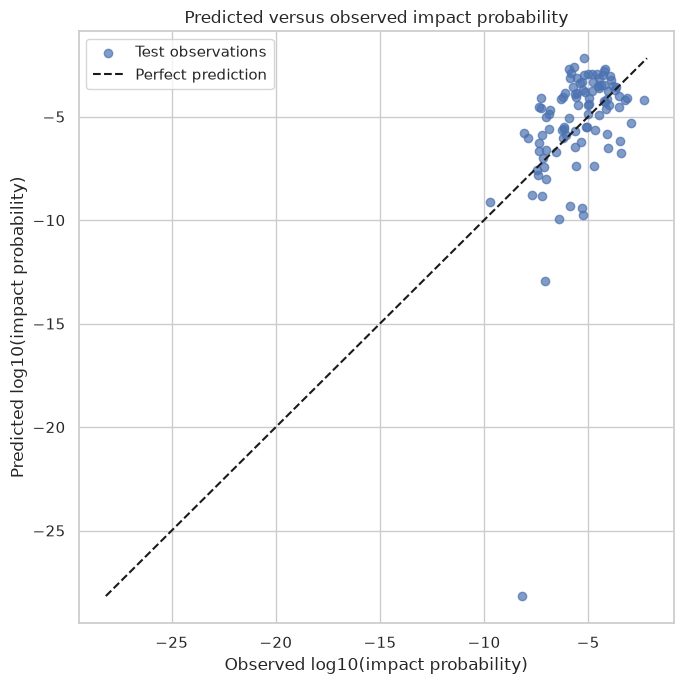

Saved figures: ['correlation_heatmap.png', 'impact_probability_distribution.png', 'predictions_vs_observations.png', 'training_history.png']
Test metrics: {'MAE': 1.6406, 'RMSE': 2.7059, 'R2': -2.853}


In [72]:
from pathlib import Path

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
# Exploratory analysis figure: numerical correlations.
correlations = df.select_dtypes(include="number").corr()
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(correlations, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix of numerical variables")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

# Exploratory analysis figure: target distribution on a logarithmic scale.
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(np.log10(df["impact_probability"]), bins=30, kde=True, ax=ax)
ax.set_title("Distribution of impact probability")
ax.set_xlabel("log10(impact probability)")
ax.set_ylabel("Number of asteroids")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "impact_probability_distribution.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

# Model performance figure: training and validation losses.
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history.history["loss"], label="Training loss")
ax.plot(history.history["val_loss"], label="Validation loss")
ax.set_title("Training history")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean squared error")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "training_history.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

# Model performance figure: predictions versus observations on the log scale.
y_pred = model.predict(X_test, verbose=0).ravel()
metrics = {
    "MAE": mean_absolute_error(y_test, y_pred),
    "RMSE": mean_squared_error(y_test, y_pred) ** 0.5,
    "R2": r2_score(y_test, y_pred),
}
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred, alpha=0.7, label="Test observations")
limits = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(limits, limits, "k--", label="Perfect prediction")
ax.set_title("Predicted versus observed impact probability")
ax.set_xlabel("Observed log10(impact probability)")
ax.set_ylabel("Predicted log10(impact probability)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "predictions_vs_observations.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

pd.DataFrame([metrics]).to_csv(Path("../reports/model_metrics.csv"), index=False)
print("Saved figures:", sorted(path.name for path in FIGURES_DIR.glob("*.png")))
print("Test metrics:", {name: round(value, 4) for name, value in metrics.items()})